<a href="https://colab.research.google.com/github/Jruiztr28/IA-y-Minirobots/blob/main/Tarea5_RedesNeuronales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Ejercicio 1**

Para realizar este ejercicio, se utilizo el conjunto de datos **load_digits**,  de Scikit-learn, que contiene imágenes de dígitos escritos a mano representadas mediante valores numéricos. Los datos se dividen en un conjunto de entrenamiento del 90 % y uno de prueba del 10 %, esto decidido mediante prueba y error, conservando la proporción de cada dígito.

Después, las características se normalizan con StandardScaler para facilitar el entrenamiento de la red neuronal. Mediante distintas combinaciones se prueban tres arquitecturas de capas ocultas y tres límites de iteraciones en un clasificador MLPClassifier.

 Cada modelo se entrena y evalúa calculando su precisión sobre los datos de prueba, y se conserva el que obtiene el mejor resultado. Finalmente, el modelo seleccionado predice los dígitos del conjunto de prueba y muestra una comparación entre el valor real y el valor predicho para las primeras diez imágenes.

In [ ]:
# Para este codigo, se utilizo la tabla de datos

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from itertools import product

nums = load_digits()
x = nums.data
y = nums.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.1, random_state= 26, stratify=y)

scaler = StandardScaler().fit(x_train)
norma_train = scaler.transform(x_train)
norma_test = scaler.transform(x_test)



mejor_modelo = None
mejor_preci = 0
layers = [(32,16), (64,32), (128,64)]
iter = [500, 1000, 1500]
for capas, iteraciones in product(layers, iter):
    ocultas = MLPClassifier(hidden_layer_sizes=capas, activation='relu', max_iter= iteraciones, random_state=26)
    ocultas.fit(norma_train, y_train)

    evalu = accuracy_score(y_test, ocultas.predict(norma_test))
    print(f"Nuronas: {capas}, Iteraciones: {iteraciones}, Precicion: {evalu:.2%}, Iteriaciones Utilizadas: {ocultas.n_iter_}")
    if evalu > mejor_preci:
        mejor_preci = evalu
        mejor_modelo = ocultas


pre = mejor_modelo.predict(norma_test)
for i in range(10):
    print(f"Imagen {i+1}: real = {y_test[i]}, predict = {pre[i]}")




**Ejercicio 2**

Este código utiliza el conjunto de datos Fashion MNIST, compuesto por imágenes de prendas de vestir de 28 × 28 píxeles clasificadas en diez categorías.

Primero se cargan los datos de entrenamiento y prueba, se verifican sus dimensiones y se normalizan los valores de los píxeles dividiéndolos entre 255.

 Luego se construye una red neuronal secuencial que aplana cada imagen y la procesa mediante dos capas densas de 128 y 64 neuronas con activación ReLU, además de una capa final de diez salidas. El modelo se configura con el optimizador Adam y la función de pérdida SparseCategoricalCrossentropy, y se entrena durante 100 épocas utilizando los datos de prueba para validación.

 Finalmente, se realizan predicciones sobre las primeras nueve imágenes y se comparan sus categorías reales con las predichas. Durante el entrenamiento aumenta considerablemente la precisión sobre los datos de entrenamiento; sin embargo, debe compararse con la precisión de validación para determinar si el modelo realmente mejora o si comienza a presentar sobreajuste.

In [ ]:
from tensorflow import keras
import numpy as np
import tensorflow as tf

clases = ["Camiseta", "Pantalon", "Sueter", "Vestido", "Abrigo", "Sandalias", "Camisa", "Tenis", "Mochila", "Botin"]

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

x_normtrain = x_train/255
x_normtest = x_test/255

modelo = tf.keras.models.Sequential([ tf.keras.layers.Flatten(input_shape=(28, 28)), tf.keras.layers.Dense(128, activation='relu'), tf.keras.layers.Dense(64, activation='relu'), tf.keras.layers.Dense(10)])
modelo.compile( optimizer=tf.keras.optimizers.Adam(0.001), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],)
H = modelo.fit(x_normtrain, y_train, epochs=100,
           validation_data=(x_normtest, y_test))

logits = modelo.predict(x_normtest[:9], verbose=0)
for i in range(9):
    pred = np.argmax(logits[i])
    print(f"Imagen {i + 1}: real = {clases[y_test[i]]}, prediccion = {clases[pred]}")




El modelo presenta una precisión bastante baja al realizar el entrenamiento a bajas épocas, mientras que a medida que se aumentan las épocas, la precisión en entrenamiento aumenta drásticamente de un 82.60% en el inicio a 	97.97% en la última época, lo cual indica que al aumentar las épocas en conjunto con las neuronas utilizadas y un ajuste fino del porcentaje de entrenamiento, la precisión que tendrá la red neuronal puede maximizarse bastante.

**Ejercicio 3**

Mediante el codigo del ejercicio 2, se pueden explicar las siguientes funciones e instrucciones:

In [ ]:
from tensorflow import keras
import numpy as np
import tensorflow as tf

tensorflow: Permite construir, entrenar y evaluar la red neuronal.


numpy: Procesa arreglos y localizar la clase con mayor precision


keras: Permite trabajar con modelos de aprendizaje automatico mediante su interfaz.

In [ ]:
clases = ["Camiseta", "Pantalon", "Sueter", "Vestido", "Abrigo", "Sandalias", "Camisa", "Tenis", "Mochila", "Botin"]

Esta lista relaciona las etiquetas numéricas del conjunto de datos, de 0 a 9, con los nombres de las prendas correspondientes definidos en el dataset cargado.

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
assert x_train.shape == (60000, 28, 28)
assert x_test.shape == (10000, 28, 28)
assert y_train.shape == (60000,)
assert y_test.shape == (10000,)

La función **load_data()** descarga y divide automáticamente los datos.


**x_train**: Se asignan imagenes para entrenar el modelo


**y_train**: Son las clases reales de las imagenes de entrenamiento.


**x_test**: Imagenes utilizadas para evaluar el modelo.


**y_test**: Clases reales de las imagenes de prueba.

Por otra parte, las instrucciones assert comprueban que los datos tengan las dimensiones esperadas.

In [ ]:
x_normtrain = x_train / 255
x_normtest = x_test / 255

**x_normtrain** y **x_normtest** trasnforma las imagenes en pixeles con valores entre 0 y 1, facilitando el entrenamiento y ayuda a que la red converja más estable.

In [ ]:
modelo = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10)
])

En este apartado se construye el modelo dividiéndose en las siguientes capas:

Sequential: Organiza las capas para que la salida de una se convierta en la entrada de la siguiente.

Flatten: Convierte cada imagen de 28 x 28 en un vector de 784 valores.

Dense: crea las capas ocultas y salidas dentro de la red, la primera cada Dense contiene 128 neuronas con activacion ReLU, la cual permite calculos sumamente rapidos, la segunda capa Dense, contiene 64 neuronas igualmente con activacion ReLU, mientras que la última capa Dense define las salidas de esta red, basándose en el número de clases definidas en el dataset.

In [ ]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy()
    ]
)

**Adam**: Algoritmo de optimización que se utiliza para entrenar redes neuronales y modelos de aprendizaje profundo. Ajusta los pesos de la red con una tasa de aprendizaje de 0.001.

**SparseCategoricalCrossentropy**: calcula el error entre la clase real y las salidas del modelo.

**from_logits**=True: indica que la última capa entrega logits y no probabilidades.

**SparseCategoricalAccuracy**: calcula el porcentaje de imágenes clasificadas correctamente.


In [ ]:
H = modelo.fit(
    x_normtrain,
    y_train,
    epochs=100,
    validation_data=(x_normtest, y_test)
)

Se definen las épocas que entrenará el modelo, las que representan un recorrido completo por las 60000 imágenes de entrenamiento. **H** conserva el historial de pérdida y precisión de cada época.

Los datos de prueba se emplean aquí como validación.

In [ ]:
logits = modelo.predict(x_normtest[:9], verbose=0)

Esta línea genera predicciones para las primeras 9 imágenes del conjunto de prueba; cada predicción posee 10 valores, uno por cada categoría.

In [ ]:
pred = np.argmax(logits[i])

**np.argmax** obtiene la posición del valor más alto, que corresponde a la categoría seleccionada por el modelo.

In [ ]:
print(
    f"Imagen {i + 1}: real = {clases[y_test[i]]}, "
    f"predicción = {clases[pred]}"
)

Finalmente, se compara la clase real con la predicción de la red.

En conclusión, el modelo logra aprender las características mediante 2 capas ocultas, ajustando sus hiperparámetros para maximizar este aprendizaje.

La normalización de las imágenes facilita el entrenamiento de la red y mejora la estabilidad del modelo.

Al aumentar el número de épocas, la precisión del entrenamiento puede cambiar drásticamente, como en este caso, pasó de un 82,60 % al inicio a un 97,97 % al final. Aunque si la precisión de entrenamiento continúa aumentando mientras la precisión de validación se mantiene o disminuye, el modelo está presentando sobreajuste.

Ejercicio 4

Using Colab cache for faster access to the 'fashionmnist' dataset.
['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']
(60000, 785)
Index(['label', 'pixel1', 'pixel2'], dtype='object')
label
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.5008 - sparse_categorical_accuracy: 0.8205 - val_loss: 0.3983 - val_sparse_categorical_accuracy: 0.8562
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3744 - sparse_categorical_accuracy: 0.8637 - val_loss: 0.3522 - val_sparse_categorical_accuracy: 0.8719
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.3393 - sparse_categorical_accuracy: 0.8757 - val_loss: 0.3523 - val_sparse_categorical_accuracy: 0.8725
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.3148 - sparse_categorical_accuracy: 0.8826 - val_loss: 0.3267 - val_sparse_categorical_accuracy: 0.8783
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2984 - sparse_categorical_accuracy: 0.8890 - val_loss: 0.3427 - val_sparse_categorical_accuracy: 0.8711
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2811 - sparse_categorical_accuracy: 0.8947 - val_loss: 0.3015 - val_sparse_categorical_accurac

Imagen 1: real = Camiseta, prediccion = Camiseta
Imagen 2: real = Pantalon, prediccion = Pantalon
Imagen 3: real = Sueter, prediccion = Sueter
Imagen 4: real = Sueter, prediccion = Sueter
Imagen 5: real = Vestido, prediccion = Abrigo
Imagen 6: real = Sueter, prediccion = Camisa
Imagen 7: real = Mochila, prediccion = Mochila
Imagen 8: real = Camisa, prediccion = Abrigo
Imagen 9: real = Sandalias, prediccion = Sandalias


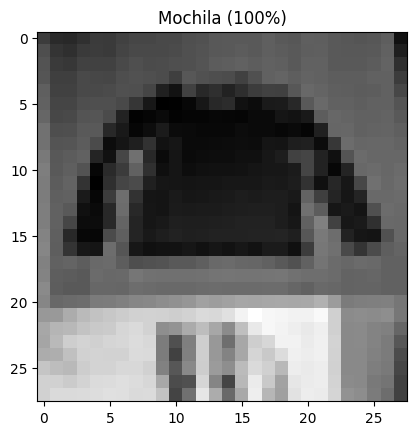

In [6]:
import kagglehub, os
import pandas as pd
import numpy as np
from tensorflow import keras
import tensorflow as tf
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import requests

path = kagglehub.dataset_download("zalando-research/fashionmnist")
print(os.listdir(path))

train = pd.read_csv(os.path.join(path, "fashion-mnist_train.csv"))
test  = pd.read_csv(os.path.join(path, "fashion-mnist_test.csv"))

print(train.shape)
print(train.columns[:3])
print(train["label"].value_counts().sort_index())

clases = ["Camiseta", "Pantalon", "Sueter", "Vestido", "Abrigo", "Sandalias", "Camisa", "Tenis", "Mochila", "Botin"]

x_normtrain = train.drop("label", axis=1).values.reshape(-1, 28, 28) / 255
y_train = train["label"].values
x_normtest  = test.drop("label", axis=1).values.reshape(-1, 28, 28) / 255
y_test  = test["label"].values

modelo = tf.keras.models.Sequential([ tf.keras.layers.Flatten(input_shape=(28, 28)), tf.keras.layers.Dense(128, activation='relu'), tf.keras.layers.Dense(64, activation='relu'), tf.keras.layers.Dense(10)])
modelo.compile( optimizer=tf.keras.optimizers.Adam(0.001), loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],)
H = modelo.fit(x_normtrain, y_train, epochs=100,
           validation_data=(x_normtest, y_test))

logits = modelo.predict(x_normtest[:9], verbose=0)
for i in range(9):
    pred = np.argmax(logits[i])
    print(f"Imagen {i + 1}: real = {clases[y_test[i]]}, prediccion = {clases[pred]}")


def predecir(ruta):
    img = Image.open(ruta).convert("L")
    img = ImageOps.invert(img)          # solo si el fondo es blanco
    img = img.resize((28, 28))
    x = np.array(img).reshape(1, 28, 28) / 255.0
    prob = tf.nn.softmax(modelo.predict(x, verbose=0)[0]).numpy()
    plt.imshow(img, cmap="gray")
    plt.title(f"{clases[prob.argmax()]} ({prob.max():.0%})")
    plt.show()

url = "https://upload.wikimedia.org/wikipedia/commons/e/e4/T-shirt_mocup_white.jpg"
ruta = "imagen_prueba.jpg"

# Descarga alternativa usando un User-Agent para evitar el bloqueo 403
headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"}
response = requests.get(url, headers=headers)
with open(ruta, "wb") as f:
    f.write(response.content)

predecir(ruta)

Debido a que las imágenes utilizadas para el entrenamiento de MNIST presentan imágenes previamente preparadas, al cargar una imagen real, constantemente la confunde con otra prenda de ropa, dado que sus siluetas son sumamente parecidas.

**Ejercicio 5**

Este código utiliza el conjunto de datos `Iris`, disponible mediante TensorFlow Datasets, para clasificar flores en tres especies: *Iris setosa*, *Iris versicolor* y *Iris virginica*.

Los datos contienen cuatro características numéricas de cada flor, correspondientes a las medidas del sépalo y del pétalo. Primero, el conjunto se convierte en arreglos de NumPy y se divide en datos de entrenamiento y prueba, reservando un 35 % para evaluación y conservando la proporción de cada especie, esto se realizó mediante pruebas, donde se determinó que un 35 generaba un mayor porcentaje de entrenamiento.

 Después, las características se normalizan con `StandardScaler` para facilitar el aprendizaje. Luego , se construye una red neuronal con dos capas ocultas de 32 y 16 neuronas con activación ReLU y una capa final de tres salidas.


 El modelo se configura con el optimizador Adam, la función de pérdida de entropía cruzada y una métrica de precisión, y se entrena durante 300 épocas.

 Finalmente, se generan predicciones para las primeras nueve muestras del conjunto de prueba y se compara la especie real con la predicha. Aunque el programa utiliza la palabra `Imagen` en la salida, sería más apropiado utilizar `Muestra`, ya que Iris contiene mediciones numéricas de flores y no imágenes.

In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from itertools import product
ds = tfds.load('iris', split = 'train', batch_size = -1, as_supervised = True)
x, y = tfds.as_numpy(ds)

clases = ["Iris setosa", "Iris versicolor", "Iris virginica"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.35, random_state= 26, stratify=y)

scaler = StandardScaler().fit(x_train)
norma_train = scaler.transform(x_train)
norma_test = scaler.transform(x_test)


modelo = tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(4,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(3)])


modelo.compile( optimizer=tf.keras.optimizers.Adam(0.001),
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=[tf.keras.metrics.SparseCategoricalAccuracy()],)


H = modelo.fit(norma_train, y_train, epochs=300,
           validation_data=(norma_test, y_test))

logits = modelo.predict(norma_test[:9], verbose=0)
for i in range(9):
    pred = np.argmax(logits[i])
    print(f"Imagen {i + 1}: real = {clases[y_test[i]]}, prediccion = {clases[pred]}")